In [3]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [4]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [5]:
def get_cutflow_and_yields_for_run_range(files, run_start=None, run_end=None, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        # if run not in good_runs: continue
        
        
        if run_start is not None and run_start > run:
            continue
        if run_end is not None and run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            # if run not in good_runs: continue


            if "initial" not in cutflow_dict:
                cutflow_dict["initial"] = {"all": 0, "passed": 0}
                
            cutflow_dict["initial"]["all"] += df["all"].max()
            cutflow_dict["initial"]["passed"] += df["all"].max()
            cutflow_dict["initial"]["efficiency"] = 1
            cutflow_dict["initial"]["cumulative_efficiency"] = 1


            
            total_lumi += lumi[0] / 1000 # /pb -> /fb
            for idx, row in df.iterrows():
                cut = row["cut_name"]
                all = row["all"]
                passed = row["passed"]

                if cut not in cutflow_dict:
                    cutflow_dict[cut] = {"all": 0, "passed": 0}

                cutflow_dict[cut]["all"] += all
                cutflow_dict[cut]["passed"] += passed
                cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[int(run)] = final_yield

    if total_lumi <= 0:
        total_lumi = 10_000

    print(f"Total lumi for runs {run_start} to {run_end}: {total_lumi:.2f} fb^-1")

    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow["rate_error [events/fb/tonne]"] = np.sqrt(cutflow["passed"]) / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [6]:
def wrap_math_text(s, caption="My table"):
    s = s.replace(r"\begin{table}", "")
    s = s.replace(r"\end{table}", "")
    s = s.replace(r"<", r"$<$").replace(r">", r"$>$").replace("=", r"$=$").replace("+", r"$+$").replace("-", r"$-$").replace("*", r"$*$").replace("/", r"$/$").replace("<=", r"$\leq$").replace(">=", r"$\geq$").replace("!=", r"$\neq$")
    s = rf"""
\begin{{table}}
\centering
\caption{{{caption}}}
\begin{{adjustbox}}{{max width=\textwidth}}
{s}
\end{{adjustbox}}
\end{{table}}
"""
    return s

In [7]:

def write_cutflow_to_latex(cutflow_df, filename="cutflow.tex", caption="Cutflow"):
    
    with open(filename, 'w') as f:

        longtable = False
        float_format = "{:0.2f}".format
        colums = ["passed", "efficiency", "cumulative_efficiency", "rate [events/fb/tonne]"]

        f.write(r"\documentclass{article}" + "\n")
        f.write(r"\usepackage{graphicx}" + "\n")
        f.write(r"\usepackage{booktabs}" + "\n")
        f.write(r"\usepackage{longtable}" + "\n")
        f.write(r"\usepackage{adjustbox}" + "\n")
        f.write(r"\begin{document}" + "\n")
        t = wrap_math_text(cutflow_df.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption=caption)
        f.write(t + "\n")
        f.write(r"\end{document}" + "\n") 


In [8]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200093.bck.root", "build/MC_truth_cuts_xing_150/200094.bck.root", "build/MC_truth_cuts_xing_150/200100.bck.root",], mass=1.1)
write_cutflow_to_latex(noCaloNu_cutflow_df, filename="cutflow_noCaloNuMC.tex", caption="Cutflow for MC 2024 without caloNu")

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:01<00:00,  2.43it/s]

Total lumi for runs None to None: 10000.00 fb^-1


In [9]:
withCaloNu_cutflow_df, withCaloNu_un_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200139.bck.root", "build/MC_truth_cuts_xing_150/200140.bck.root", "build/MC_truth_cuts_xing_150/200146.bck.root",], mass=0.68)
write_cutflow_to_latex(withCaloNu_cutflow_df, filename="cutflow_CaloNuMC.tex", caption="Cutflow for MC 2024 with caloNu")

100%|██████████| 3/3 [00:00<00:00,  3.25it/s]

Total lumi for runs None to None: 10000.00 fb^-1


In [10]:
display(noCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,1450841,1450841,1.000000,1.000000,NaN,131.894636,0.109501
Crossing angle = 150 in 2024 period,1450841,260895,0.179823,0.179823,0.000319,23.717727,0.046434
Remove CaloNu PMT region (truth),260895,260895,1.000000,0.179823,0.000000,23.717727,0.046434
CC events only,260895,197809,0.758194,0.136341,0.000838,17.982636,0.040432
nu_mu only,197809,165058,0.834431,0.113767,0.000836,15.005273,0.036934
At least one long track,165058,34352,0.208121,0.023677,0.000999,3.122909,0.016849
In Faser Nu Box or Lead Block,34352,26959,0.784787,0.018582,0.002217,2.450818,0.014927
Truth dec r < 100 mm,26959,16524,0.612931,0.011389,0.002967,1.502182,0.011686
Truth pz > 100 GeV,16524,16113,0.975127,0.011106,0.001212,1.464818,0.011540
VetoNu0 reduced charge < 30 pC,16113,14911,0.925402,0.010277,0.002070,1.355545,0.011101


In [11]:
display(withCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,1264895,1264895,1.000000,1.000000,NaN,186.013971,0.165393
Crossing angle = 150 in 2024 period,1264895,556898,0.440272,0.440272,0.000441,81.896765,0.109744
Remove CaloNu PMT region (truth),556898,555714,0.997874,0.439336,0.000062,81.722647,0.109627
CC events only,555714,421113,0.757787,0.332923,0.000575,61.928382,0.095431
nu_mu only,421113,350460,0.832223,0.277066,0.000576,51.538235,0.087058
At least one long track,350460,59138,0.168744,0.046753,0.000633,8.696765,0.035762
In Faser Nu Box or Lead Block,59138,36006,0.608847,0.028466,0.002007,5.295000,0.027905
Truth dec r < 100 mm,36006,21699,0.602650,0.017155,0.002579,3.191029,0.021663
Truth pz > 100 GeV,21699,21021,0.968754,0.016619,0.001181,3.091324,0.021322
VetoNu0 reduced charge < 30 pC,21021,19502,0.927739,0.015418,0.001786,2.867941,0.020537


In [12]:
def plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df):

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=1, sharex=True)
    ax[0].bar(noCaloNu_cutflow_df.index, noCaloNu_cutflow_df["rate [events/fb/tonne]"], label="No caloNu", alpha=0.7)
    ax[0].bar(withCaloNu_cutflow_df.index, withCaloNu_cutflow_df["rate [events/fb/tonne]"], label="With caloNu", alpha=0.7)
    ax[0].set_yscale("log")
    ax[0].set_ylabel("Rate [events/fb/tonne]")
    ax[0].set_title("Crossing angle: 150 mrad", loc="left")
    ax[0].set_title("Cutflow Comparison: No caloNu vs With caloNu", loc="right")
    ax[0].legend()
    ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")

    ratio = withCaloNu_cutflow_df["rate [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]
    ratio_error = np.sqrt((withCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"])**2 + (withCaloNu_cutflow_df["rate [events/fb/tonne]"] * noCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]**2)**2)
    ax[1].errorbar(noCaloNu_cutflow_df.index, ratio, yerr=ratio_error, color="gray", alpha=0.7, capsize=5, linestyle='None', marker='o')
    # ax[1].bar(noCaloNu_cutflow_df.index, ratio, color="gray", alpha=0.7)
    # ax[1].set_ylabel("Ratio (With caloNu / No caloNu)")
    # ax[1].set_xlabel("Cut Name")
    ax[1].set_ylabel("Ratio \n (With caloNu / No caloNu)")
    ax[1].axhline(1, color="red", linestyle="--")
    plt.tight_layout()


/tmp/ipykernel_1393158/3722371402.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


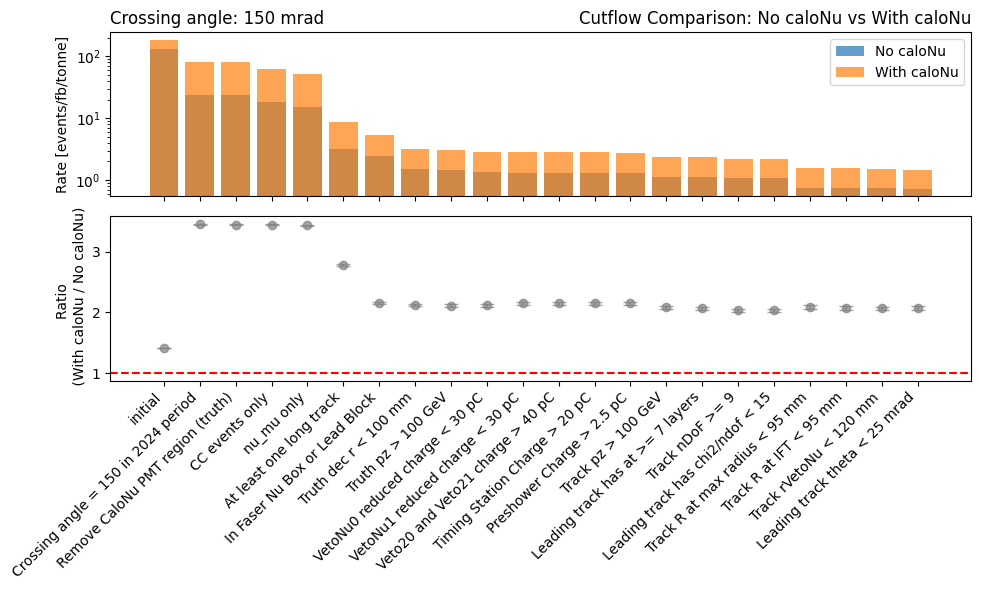

In [13]:
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 38.43it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 55.14it/s]
/tmp/ipykernel_1393158/3722371402.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


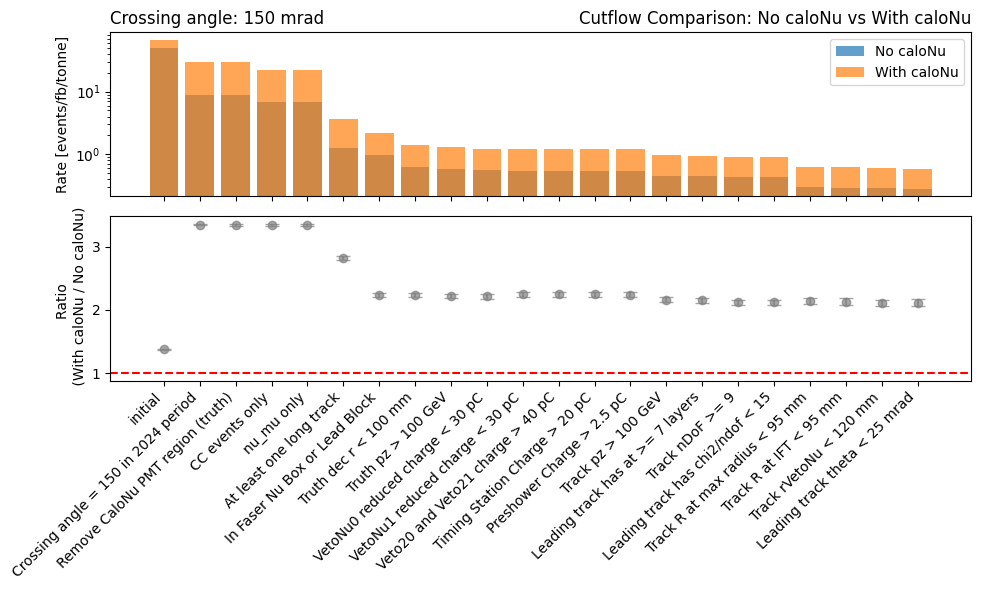

In [14]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200093.bck.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200139.bck.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 49.21it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 45.16it/s]
/tmp/ipykernel_1393158/3722371402.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


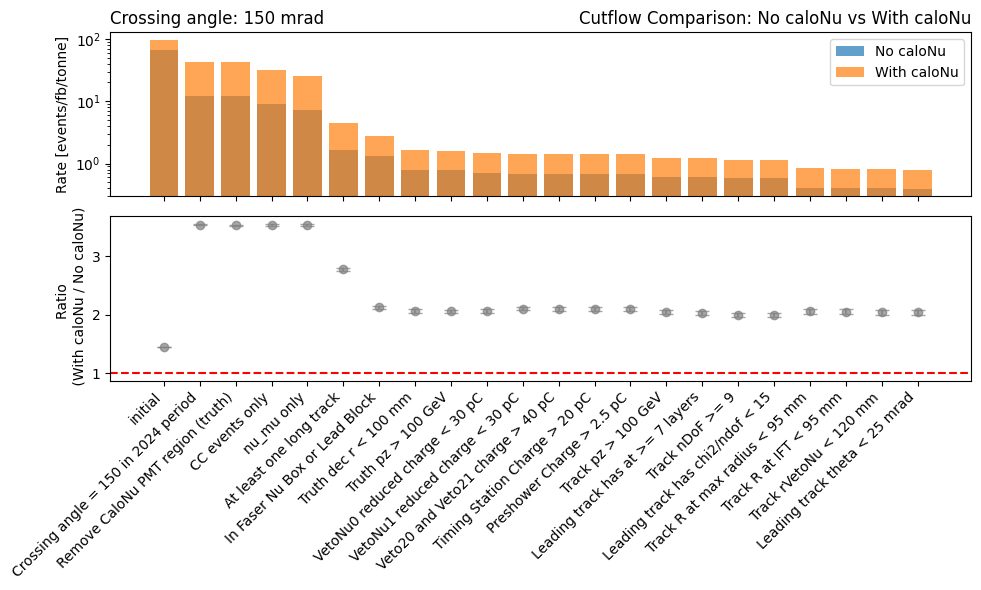

In [15]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200094.bck.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200140.bck.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 40.09it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 59.32it/s]
/tmp/ipykernel_1393158/3722371402.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


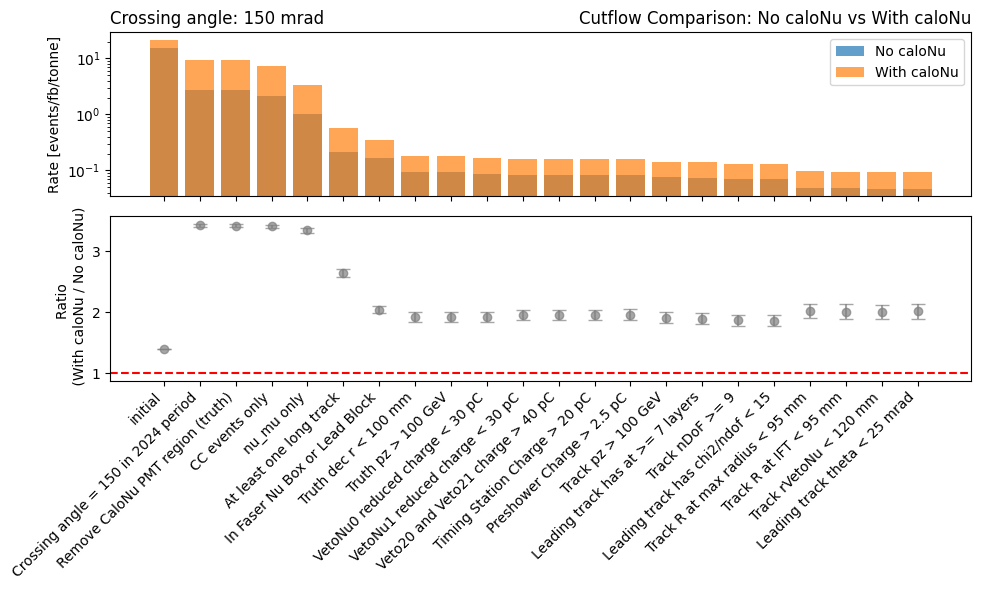

In [16]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200100.bck.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/MC_truth_cuts_xing_150/200146.bck.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [17]:
data_noCaloNu = uproot.concatenate(["build/MC_truth_cuts_xing_150/200093.bck.root:nt", "build/MC_truth_cuts_xing_150/200094.bck.root:nt", "build/MC_truth_cuts_xing_150/200100.bck.root:nt"], filter_name=["crossingAngle"])
data_withCaloNu = uproot.concatenate(["build/MC_truth_cuts_xing_150/200139.bck.root:nt", "build/MC_truth_cuts_xing_150/200140.bck.root:nt", "build/MC_truth_cuts_xing_150/200146.bck.root:nt"], filter_name=["crossingAngle"])

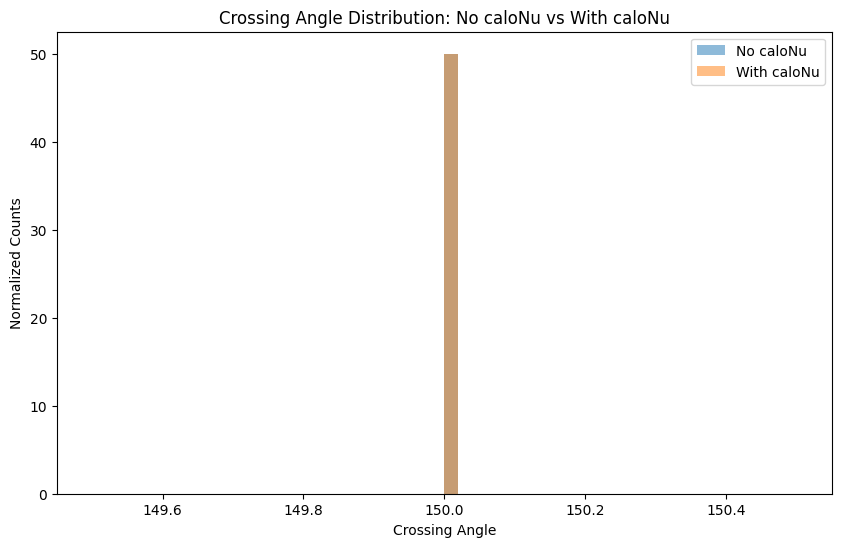

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
# bins = np.linspace(-0.5, 0.5, 50)
bins=50
ax.hist(data_noCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="No caloNu", density=True)
ax.hist(data_withCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="With caloNu", density=True)
ax.set_xlabel("Crossing Angle")
ax.set_ylabel("Normalized Counts")
ax.set_title("Crossing Angle Distribution: No caloNu vs With caloNu")
ax.legend()

In [19]:
print(set(data_noCaloNu["crossingAngle"]))
print(set(data_withCaloNu["crossingAngle"]))

{np.float32(150.0)}
{np.float32(150.0)}


In [20]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
calonu_data_files = []
no_calonu_data_files = []
for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])
    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}:nt")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        no_calonu_data_files.append(f"{file}:nt")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
            no_calonu_data_files.append(f"{file}:nt")

print(f"Found {len(calonu_data_files)} files for caloNu")
print(f"Found {len(no_calonu_data_files)} files for No caloNu")

Found 130 files for caloNu
Found 146 files for No caloNu


In [21]:
df_data_CaloNu = uproot.concatenate(calonu_data_files, library="pd", filter_name="crossingAngle")
df_data_noCaloNu = uproot.concatenate(no_calonu_data_files, library="pd", filter_name="crossingAngle")

In [22]:
bins = np.linspace(140, 170 ,30)
h_mc_noCaloNu = bh.Histogram(bh.axis.Variable(bins))
h_mc_withCaloNu = bh.Histogram(bh.axis.Variable(bins))

h_data_noCaloNu = bh.Histogram(bh.axis.Variable(bins))
h_data_withCaloNu = bh.Histogram(bh.axis.Variable(bins))

h_mc_noCaloNu.fill(data_noCaloNu["crossingAngle"])
h_mc_withCaloNu.fill(data_withCaloNu["crossingAngle"])

h_data_noCaloNu.fill(df_data_noCaloNu["crossingAngle"])
h_data_withCaloNu.fill(df_data_CaloNu["crossingAngle"]);

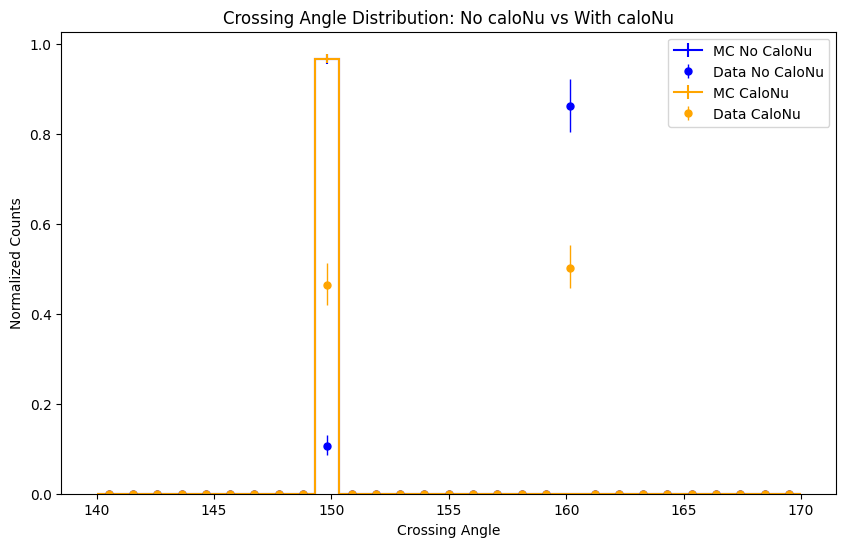

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
# bins = np.linspace(-0.5, 0.5, 50)

mplhep.histplot(h_mc_noCaloNu, histtype="step", color="blue", ax=ax, density=True, label="MC No CaloNu")
mplhep.histplot(h_data_noCaloNu, histtype="errorbar", color="blue", ax=ax, density=True, label="Data No CaloNu")


mplhep.histplot(h_mc_withCaloNu, histtype="step", color="orange", ax=ax, density=True, label="MC CaloNu")
mplhep.histplot(h_data_withCaloNu, histtype="errorbar", color="orange", ax=ax, density=True, label="Data CaloNu")



ax.set_xlabel("Crossing Angle")
ax.set_ylabel("Normalized Counts")
ax.set_title("Crossing Angle Distribution: No caloNu vs With caloNu")
ax.legend()